<a href="https://colab.research.google.com/github/danielruizm16/ComputationalMethods_2026_I/blob/main/Cálculo/Cálculo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/></a>

# Cálculo numérico

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sympy as sp
from scipy.interpolate import lagrange, CubicSpline, interp1d
from scipy.integrate import trapezoid, simpson, fixed_quad, quad, tplquad
from scipy.special import roots_legendre

# 1.
El potencial eléctrico de un anillo de radio $R$, a lo largo de su eje vertical $z$, está dado por:

$$
V = \frac{kq_{tot}}{\sqrt{z^2+R^2}}
$$

con $R=0.1$ mm. Reescale el problema en unidades de $kq_{tot}$ y luego:

- Calcule el campo eléctrico usando la biblioteca SymPy.
- Calcule el campo eléctrico en el punto $z = 0.1$ mm usando el método `np.gradient` y el método de derivada de 3 puntos.
- Compare los resultados de los tres métodos: analítico con SymPy, `np.gradient` y derivada de 3 puntos.
- Calcule el campo eléctrico para diferentes valores de $z$, con $z>0$, usando `np.gradient`. Construya una gráfica de $E$ vs. $z$.

---
Recuerde que la componente $z$ del campo eléctrico está dada por:

$$
E_z = - \frac{\partial V}{\partial z}
$$

In [2]:
# Parámetro dado
R = 1e-4  # m
z_objetivo = 1e-4  # m

# Definir símbolos
z_sym = sp.Symbol('z')
R_sym = sp.Symbol('R')
k_sym = sp.symbols('k')
q_sym = sp.symbols('q_{tot}')

# Potencial eléctrico
V = k_sym * q_sym / sp.sqrt(z_sym**2 + R_sym**2)

V

k*q_{tot}/sqrt(R**2 + z**2)

In [3]:
# Reescalar el potencial
V = V / (k_sym * q_sym)

# Campo eléctrico (Ez = -dV/dz)
Ez_analitico = -sp.diff(V, z_sym)
print('El campo eléctrico en unidades de kqtot está dado por:')
Ez_analitico

El campo eléctrico en unidades de kqtot está dado por:


z/(R**2 + z**2)**(3/2)

In [4]:
# Sustituir R = 0.1 mm
V = V.subs(R_sym, R)
Ez_analitico = Ez_analitico.subs(R_sym, R)

In [5]:
# Solución analítica en z = 0.1 mm
E_analitico_z01 = float(Ez_analitico.subs(z_sym, z_objetivo))
print(f'Valor del campo en z = 0.1 mm de forma analítica: Ez = {E_analitico_z01:.3}')

Valor del campo en z = 0.1 mm de forma analítica: Ez = 3.54e+07


In [6]:
# Definir V como una función para operar con ella

# V = lambda z: 1/np.sqrt(z**2 + R**2)
V = sp.lambdify(z_sym, V)

# Valores para usar en el gradiente
z_valores = np.linspace(z_objetivo, z_objetivo * 10, 100000)

# Calcular E
E_valores = -np.gradient(V(z_valores), z_valores)
E_gradiente_z01 = E_valores[0]

print(f'Valor del campo en z = 0.1 mm con np.gradient: Ez = {E_gradiente_z01:.3}')

Valor del campo en z = 0.1 mm con np.gradient: Ez = 3.54e+07


In [7]:
# Método de derivada de 3 puntos
def diferencia_central_tres_puntos(funcion, x, h=1e-5):
    """Diferencia central de 3 puntos - O(h^2)."""
    return (funcion(x + h) - funcion(x - h)) / (2 * h)

def diferencia_adelante_tres_puntos(funcion, x, h=1e-5):
    """Diferencia hacia adelante de 3 puntos - O(h^2)."""
    return (-3 * funcion(x) + 4 * funcion(x + h) - funcion(x + 2 * h)) / (2 * h)

def diferencia_atras_tres_puntos(funcion, x, h=1e-5):
    """Diferencia hacia atrás de 3 puntos - O(h^2)."""
    return (3 * funcion(x) - 4 * funcion(x - h) + funcion(x - 2 * h)) / (2 * h)

In [8]:
# Calcular usando los tres métodos de 3 puntos
E_3puntos_central_z01 = -diferencia_central_tres_puntos(V, z_objetivo)
E_3puntos_adelante_z01 = -diferencia_adelante_tres_puntos(V, z_objetivo)
E_3puntos_atras_z01 = -diferencia_atras_tres_puntos(V, z_objetivo)

print(f'Valor del campo en z = 0.1 mm con 3 puntos central:    Ez = {E_3puntos_central_z01:.3}')
print(f'Valor del campo en z = 0.1 mm con 3 puntos adelante:   Ez = {E_3puntos_adelante_z01:.3}')
print(f'Valor del campo en z = 0.1 mm con 3 puntos atrás:      Ez = {E_3puntos_atras_z01:.3}')

Valor del campo en z = 0.1 mm con 3 puntos central:    Ez = 3.53e+07
Valor del campo en z = 0.1 mm con 3 puntos adelante:   Ez = 3.54e+07
Valor del campo en z = 0.1 mm con 3 puntos atrás:      Ez = 3.55e+07


In [9]:
# Crear DataFrame de comparación
datos_comparacion = {
    'Método': [
        'Analítico (exacto)',
        'np.gradient', 
        'Central de 3 puntos',
        'Adelante de 3 puntos',
        'Atrás de 3 puntos'
    ],
    'E_z en z = 0.1 mm': [
        E_analitico_z01,
        E_gradiente_z01,
        E_3puntos_central_z01,
        E_3puntos_adelante_z01,
        E_3puntos_atras_z01
    ],
    'Error absoluto': [
        0.0,
        abs(E_gradiente_z01 - E_analitico_z01),
        abs(E_3puntos_central_z01 - E_analitico_z01),
        abs(E_3puntos_adelante_z01 - E_analitico_z01),
        abs(E_3puntos_atras_z01 - E_analitico_z01)
    ],
    'Error relativo (%)': [
        0.0,
        abs((E_gradiente_z01 - E_analitico_z01) / E_analitico_z01) * 100,
        abs((E_3puntos_central_z01 - E_analitico_z01) / E_analitico_z01) * 100,
        abs((E_3puntos_adelante_z01 - E_analitico_z01) / E_analitico_z01) * 100,
        abs((E_3puntos_atras_z01 - E_analitico_z01) / E_analitico_z01) * 100
    ]
}

df_comparacion = pd.DataFrame(datos_comparacion)

df_comparacion

,Método,E_z en z = 0.1 mm,Error absoluto,Error relativo (%)
0,Analítico (exacto),3.535534e+07,0.000000,0.000000
1,np.gradient,3.535454e+07,795.538873,0.002250
2,Central de 3 puntos,3.531068e+07,44662.933900,0.126326
3,Adelante de 3 puntos,3.540678e+07,51444.560109,0.145507
4,Atrás de 3 puntos,3.549372e+07,138376.933669,0.391389


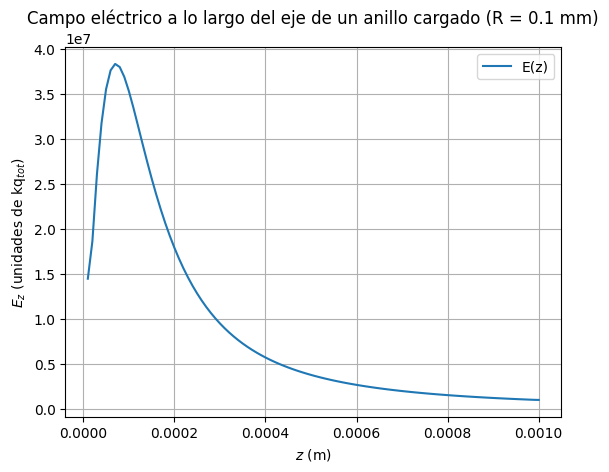

In [10]:
# Definir un nuevo rango para z
z = np.linspace(1e-5, 1e-3, 100)

# E para este rango
E = -np.gradient(V(z), z)

# Gráfica
plt.title('Campo eléctrico a lo largo del eje de un anillo cargado (R = 0.1 mm)')
plt.plot(z, E, label='E(z)')
plt.xlabel('$z$ (m)')
plt.ylabel('$E_z$ (unidades de kq$_{tot}$)')
plt.legend()
plt.grid()
plt.show()

# 2.

En un circuito con un voltaje $\varepsilon(t)$ y una inductancia $L$, la primera ley de Kirchhoff nos da la siguiente relación:

$$
\varepsilon(t) = L\frac{\mathrm{d}i}{\mathrm{d}t} + Ri
$$

donde $R$ es la resistencia del circuito e $i$ es la corriente. Suponga que medimos la corriente para varios valores de $t$ y obtenemos:

```
t = np.array([1.00, 1.01, 1.02, 1.03, 1.04])  # tiempo
i = np.array([3.10, 3.12, 3.14, 3.18, 3.24])  # corriente
```

donde $t$ se mide en segundos, $i$ está dada en amperios, la inductancia es $L= 0.98$ H y la resistencia es $0.142 \Omega$. Aproxime el voltaje $\varepsilon(t)$ en los valores $t=1.00,\ 1.01,\ 1.02,\ 1.03,\ 1.04$. Para ello, realice los siguientes pasos:

- Cree un DataFrame de pandas con los valores de tiempo y corriente.
- Use el método de diferencias finitas y la fórmula de tres puntos para calcular la derivada numérica.
- Ahora, encuentre un polinomio de interpolación usando uno de los métodos discutidos y calcule la derivada “exacta”. Compare sus resultados.

In [11]:
# Datos dados
t = np.array([1.00, 1.01, 1.02, 1.03, 1.04])  # tiempo
i = np.array([3.10, 3.12, 3.14, 3.18, 3.24])  # corriente
L = 0.98  # H
R = 0.142  # Ω

In [12]:
df = pd.DataFrame({'t': t, 'i': i})
df

,t,i
0,1.00,3.10
1,1.01,3.12
2,1.02,3.14
3,1.03,3.18
4,1.04,3.24


In [13]:
di_dt = np.gradient(df['i'], df['t'], edge_order=2)
df['di_dt'] = di_dt
df

,t,i,di_dt
0,1.00,3.10,2.0
1,1.01,3.12,2.0
2,1.02,3.14,3.0
3,1.03,3.18,5.0
4,1.04,3.24,7.0


In [14]:
def diferencias_finitas(y, x):
    """
    Calcula la derivada usando diferencias finitas.
    Para puntos interiores: f'(x) ≈ (f(x+h) - f(x-h)) / (2h).
    Para los extremos: usa diferencia hacia adelante o hacia atrás.
    """
    h = x[1] - x[0]  # Se asume espaciamiento uniforme
    n = len(x)  # Número de puntos
    dy_dx = np.zeros(n)  # Arreglo para las derivadas

    for indice in range(n):
        if indice == 0:
            # Derivada hacia adelante para el primer punto
            dy_dx[indice] = (y[indice + 1] - y[indice]) / h
        elif indice == n - 1:
            # Derivada hacia atrás para el último punto
            dy_dx[indice] = (y[indice] - y[indice - 1]) / h
        else:
            # Diferencia central para los demás puntos
            dy_dx[indice] = (y[indice + 1] - y[indice - 1]) / (2 * h)
    return dy_dx

In [15]:
def derivada_tres_puntos(y, x):
    """
    Calcula la derivada usando la fórmula de tres puntos.
    """
    h = x[1] - x[0]  # Se asume espaciamiento uniforme
    n = len(x)  # Número de puntos
    derivada = np.zeros(n)  # Arreglo para las derivadas

    for indice in range(n):
        if indice == 0:
            # Derivada hacia adelante para el primer punto
            derivada[indice] = (-3 * y[indice] + 4 * y[indice + 1] - y[indice + 2]) / (2 * h)
        elif indice == n - 1:
            # Derivada hacia atrás para el último punto
            derivada[indice] = (3 * y[indice] - 4 * y[indice - 1] + y[indice - 2]) / (2 * h)
        else:
            # Diferencia central para los demás puntos
            derivada[indice] = (y[indice + 1] - y[indice - 1]) / (2 * h)

    return derivada

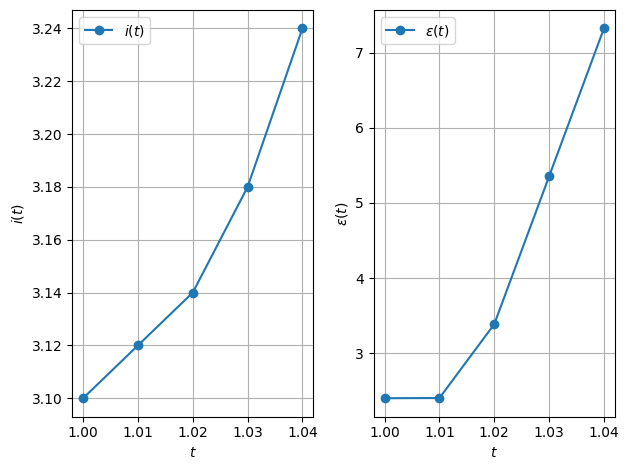

In [16]:
def epsilon(L, R, di_dt, i):
    return L * di_dt + R * i

df['epsilon'] = epsilon(L, R, df['di_dt'], df['i'])

fig, ax = plt.subplots(1, 2)
ax[0].plot(df['t'], df['i'], 'o-', label='$i(t)$')
ax[0].set_xlabel('$t$')
ax[0].set_ylabel('$i(t)$')
ax[0].legend()
ax[0].grid()

ax[1].plot(df['t'], df['epsilon'], 'o-', label=r'$\epsilon(t)$')
ax[1].set_xlabel('$t$')
ax[1].set_ylabel(r'$\epsilon(t)$')
ax[1].grid()
ax[1].legend()

plt.tight_layout()
plt.show()

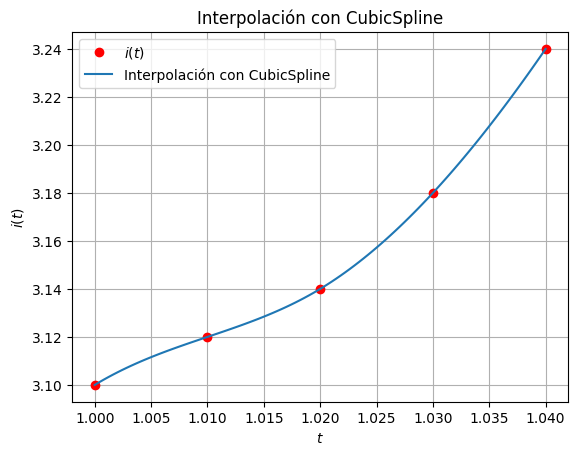

In [17]:
Pn = CubicSpline(df['t'], df['i'])
Pn_prima = Pn.derivative()
t_interp = np.linspace(df['t'].min(), df['t'].max(), 100)
i_interp = Pn(t_interp)

plt.title('Interpolación con CubicSpline')
plt.plot(df['t'], df['i'], 'ro', label='$i(t)$')
plt.plot(t_interp, i_interp, label='Interpolación con CubicSpline')
plt.xlabel('$t$')
plt.ylabel('$i(t)$')
plt.legend()
plt.grid()
plt.show()

In [18]:
# Calcular la derivada exacta en nuestros puntos de datos
di_dt_exacto = Pn_prima(t)

# Calcular el voltaje usando la derivada exacta
epsilon_exacto = L * di_dt_exacto + R * i

df['di_dt_exacto'] = di_dt_exacto
df['epsilon_exacto'] = epsilon_exacto

# Calcular diferencias
df['Error_absoluto_di_dt'] = np.abs(df['di_dt'] - df['di_dt_exacto'])
df['Error_absoluto_epsilon'] = np.abs(df['epsilon'] - df['epsilon_exacto'])

df

,t,i,di_dt,epsilon,di_dt_exacto,epsilon_exacto,Error_absoluto_di_dt,Error_absoluto_epsilon
0,1.00,3.10,2.0,2.40020,2.833333,3.216867,0.833333,0.816667
1,1.01,3.12,2.0,2.40304,1.583333,1.994707,0.416667,0.408333
2,1.02,3.14,3.0,3.38588,2.833333,3.222547,0.166667,0.163333
3,1.03,3.18,5.0,5.35156,5.083333,5.433227,0.083333,0.081667
4,1.04,3.24,7.0,7.32008,6.833333,7.156747,0.166667,0.163333


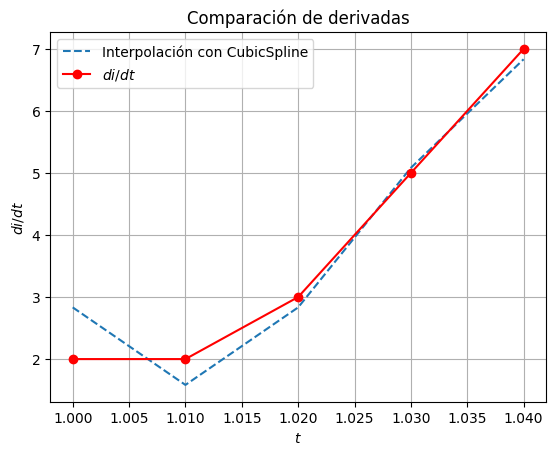

In [19]:
plt.plot(df['t'], Pn_prima(df['t']), '--', label='Interpolación con CubicSpline')
plt.plot(df['t'], df['di_dt'], 'ro-', label='$di/dt$')
plt.title('Comparación de derivadas')
plt.xlabel('$t$')
plt.ylabel('$di/dt$')
plt.legend()
plt.grid()
plt.show()

# 3.
Usando los siguientes datos de tiempo y distancia:

```
t = np.array([0, 3, 5, 8, 10, 13])  # Tiempo en s
x = np.array([0, 225, 383, 623, 742, 993])  # Distancia recorrida en m
```

- Determine la velocidad instantánea para cada uno de los tiempos y distancias mostrados.

- ¿Cuál será la velocidad en $t=12$?

In [20]:
# Datos proporcionados
t = np.array([0, 3, 5, 8, 10, 13])  # Tiempo en s
x = np.array([0, 225, 383, 623, 742, 993])  # Distancia en m

In [21]:
# Calcular la velocidad instantánea (derivada de x con respecto a t)
v = np.gradient(x, t)

In [22]:
# Mostrar las velocidades en cada instante
print("Velocidades instantáneas:")
for tiempo, velocidad in zip(t, v):
    print(f"t = {tiempo} s → v = {velocidad:.2f} m/s")

Velocidades instantáneas:
t = 0 s → v = 75.00 m/s
t = 3 s → v = 77.40 m/s
t = 5 s → v = 79.40 m/s
t = 8 s → v = 67.70 m/s
t = 10 s → v = 69.17 m/s
t = 13 s → v = 83.67 m/s


In [23]:
# Interpolación lineal
interp_lineal = interp1d(t, v, kind='linear', fill_value='extrapolate')
v_12_lineal = interp_lineal(12)

# Interpolación de Lagrange
polinomio_lagrange = lagrange(t, v)
v_12_lagrange = polinomio_lagrange(12)

# Splines cúbicos
spline_cubico = CubicSpline(t, v, extrapolate=True)
v_12_spline = spline_cubico(12)

# Resultados
print("Velocidad en t = 12 s:")
print(f"- Lineal: {v_12_lineal:.2f} m/s")
print(f"- Lagrange: {v_12_lagrange:.2f} m/s")
print(f"- Spline cúbico: {v_12_spline:.2f} m/s")

Velocidad en t = 12 s:
- Lineal: 78.83 m/s
- Lagrange: 81.56 m/s
- Spline cúbico: 78.30 m/s


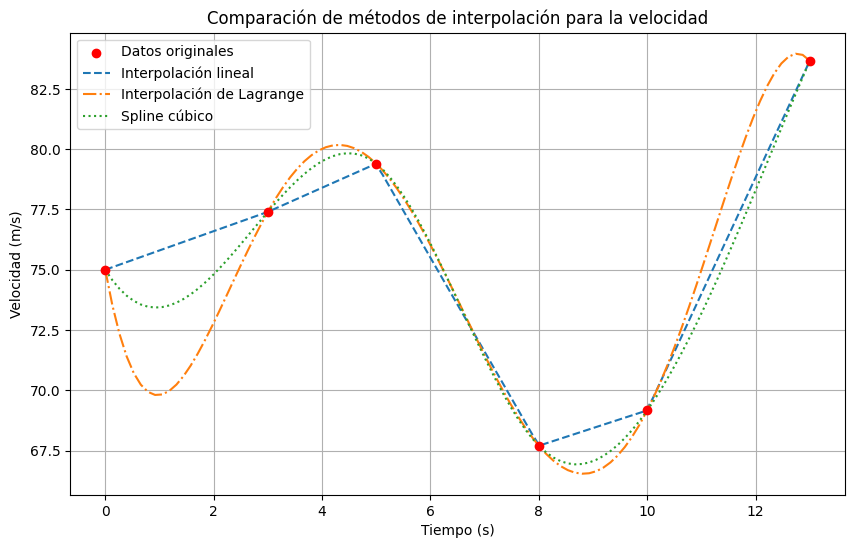

In [24]:
# Gráfica comparativa
t_valores = np.linspace(0, 13, 100)  # Puntos para graficar las interpolaciones
v_lineal = interp_lineal(t_valores)
v_lagrange = polinomio_lagrange(t_valores)
v_spline_cubico = spline_cubico(t_valores)

plt.figure(figsize=(10, 6))
plt.scatter(t, v, color='red', label='Datos originales', zorder=5)
plt.plot(t_valores, v_lineal, label='Interpolación lineal', linestyle='--')
plt.plot(t_valores, v_lagrange, label='Interpolación de Lagrange', linestyle='-.')
plt.plot(t_valores, v_spline_cubico, label='Spline cúbico', linestyle=':')
# plt.axvline(x=12, color='gray', linestyle=':', label='t = 12 s')
plt.title("Comparación de métodos de interpolación para la velocidad")
plt.xlabel("Tiempo (s)")
plt.ylabel("Velocidad (m/s)")
plt.legend()
plt.grid()
plt.show()

# 4.
La teoría de Debye para sólidos proporciona la capacidad calorífica de un sólido a temperatura $T$ como:

$$C_V = 9V \rho k_B \left( \frac{T}{\theta_D} \right)^3 \int_0^{\theta_D / T} \frac{x^4 e^x}{(e^x - 1)^2} \, dx$$

donde $V$ = volumen del sólido, $\rho$ = densidad numérica de átomos, $k_B$ = constante de Boltzmann y $\theta_D$ = temperatura de Debye (propiedad del material).

- Escriba una función de Python `cv(T)` que calcule $C_V$ para un valor dado de temperatura, para una muestra de aluminio con:
    - Volumen $V = 1000$ $cm^3$
    - Densidad $\rho = 6.022 \times 10^{28}$ $m^{-3}$
    - Temperatura de Debye $\theta_D = 428$ K

Use los métodos del trapecio y de Simpson para evaluar la integral.

- Use su función para graficar la capacidad calorífica como función de la temperatura desde $T = 5$ K hasta $T = 500$ K.

In [25]:
# Constantes y parámetros del material (aluminio)
V = 1000 * 1e-6  # Volumen en m³ (convertido desde cm³)
rho = 6.022e28  # Densidad atómica en m⁻³
theta_D = 428  # Temperatura de Debye en K
kB = 1.380649e-23  # Constante de Boltzmann en J/K

In [26]:
# Función integrando de la teoría de Debye
def integrando(x):
    return (x**4 * np.exp(x)) / (np.exp(x) - 1)**2

In [27]:
def trapecio_compuesto(f, a, b, n):
    """
    Calcula la integral definida usando la regla compuesta del trapecio.

    Parámetros:
    f : función que se va a integrar
    a : límite inferior
    b : límite superior
    n : número de subintervalos

    Retorna:
    float: valor de la integral
    """
    if n <= 0:
        raise ValueError("El número de subintervalos debe ser positivo")

    h = (b - a) / n

    # Calcular la suma de los valores de la función en los puntos interiores
    suma = 0
    for j in range(1, n):
        suma += f(a + j * h)

    # Fórmula compuesta del trapecio
    integral = (h / 2) * (f(a) + f(b)) + h * suma

    return integral

In [28]:
# Función para calcular C_V usando el método del trapecio
def cv_trapecio(T):
    lim_inf = 1e-6
    lim_sup = theta_D / T
    integral = trapecio_compuesto(integrando, lim_inf, lim_sup, 30)
    return 9 * V * rho * kB * (T / theta_D)**3 * integral

In [29]:
def simpson_13_compuesto(f, a, b, n):
    """
    Calcula la integral definida usando la regla compuesta de Simpson 1/3.

    Parámetros:
    f : función que se va a integrar
    a : límite inferior
    b : límite superior
    n : número de subintervalos (debe ser par)

    Retorna:
    float: valor de la integral
    """
    if n <= 0:
        raise ValueError("El número de subintervalos debe ser positivo")
    if n % 2 != 0:
        raise ValueError("El número de subintervalos debe ser par para la regla de Simpson 1/3")

    h = (b - a) / n

    # Calcular las sumas
    suma_4 = 0  # puntos con coeficiente 4 (índices impares)
    suma_2 = 0  # puntos con coeficiente 2 (índices pares)

    # Iterar sobre los puntos interiores
    for j in range(1, n):
        x = a + j * h
        if j % 2 == 1:  # índices impares: coeficiente 4
            suma_4 += f(x)
        else:  # índices pares: coeficiente 2
            suma_2 += f(x)

    # Fórmula compuesta de Simpson 1/3
    integral = (h / 3) * (f(a) + 4 * suma_4 + 2 * suma_2 + f(b))

    return integral

In [30]:
# Función para calcular C_V usando el método de Simpson
def cv_simpson(T):
    lim_inf = 1e-6
    lim_sup = theta_D / T
    integral = simpson_13_compuesto(integrando, lim_inf, lim_sup, 30)
    return 9 * V * rho * kB * (T / theta_D)**3 * integral

In [31]:
# Rango de temperaturas para graficar
T_valores = np.linspace(5, 500, 100)  # Desde 5 K hasta 500 K

In [32]:
# Calcular C_V para cada temperatura
Cv_trap = [cv_trapecio(T) for T in T_valores]
Cv_simp = [cv_simpson(T) for T in T_valores]

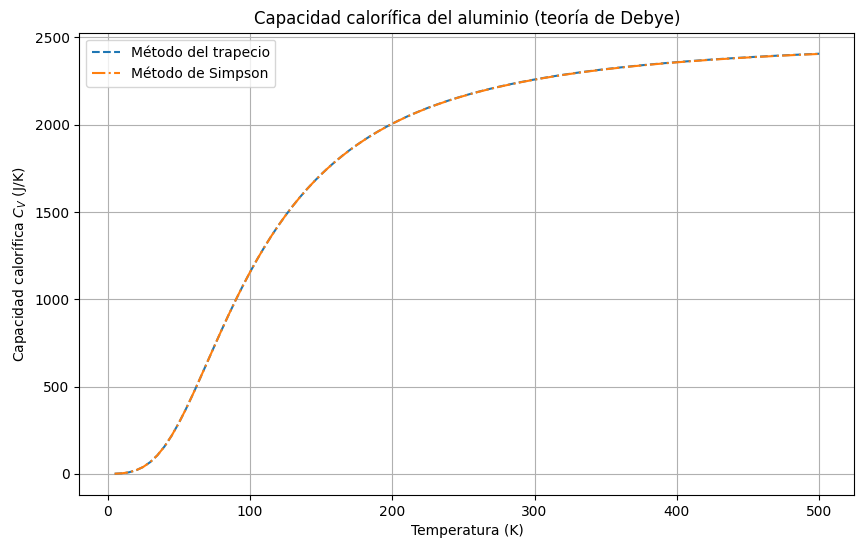

In [33]:
# Graficar los resultados
plt.figure(figsize=(10, 6))
plt.plot(T_valores, Cv_trap, label='Método del trapecio', linestyle='--')
plt.plot(T_valores, Cv_simp, label='Método de Simpson', linestyle='-.')
plt.xlabel('Temperatura (K)')
plt.ylabel('Capacidad calorífica $C_V$ (J/K)')
plt.title('Capacidad calorífica del aluminio (teoría de Debye)')
plt.grid()
plt.legend()
plt.show()

## Implementación con scipy

In [34]:
# Función para calcular C_V con el método del trapecio
def cv_trapecio_scipy(T):
    x_max = theta_D / T
    x = np.linspace(1e-6, x_max, 1000)  # Puntos de integración
    y = integrando(x)
    integral = trapezoid(y, x)
    return 9 * V * rho * kB * (T / theta_D)**3 * integral

In [35]:
# Función para calcular C_V con el método de Simpson
def cv_simpson_scipy(T):
    x_max = theta_D / T
    x = np.linspace(1e-6, x_max, 1000)
    y = integrando(x)
    integral = simpson(y, x)
    return 9 * V * rho * kB * (T / theta_D)**3 * integral

## Para la Tarea 5 se debe implementar trapecio y Simpson, pero definiendo una tolerancia.

# 5.
Una espira de corriente de radio $a$ transporta una corriente $I$ en el punto $P$, que se encuentra a una distancia $r$ del centro de la espira con coordenadas esféricas $(r,\theta, \varphi)$. Resuelva la componente $\varphi$ del potencial vectorial en el punto $P$ en términos de integrales elípticas:

$$
A_{\varphi}(r, \theta)=\frac{\mu_0}{4\pi}\frac{4Ia}{\sqrt{a^2+r^2+2ar\sin \theta}}\left(\frac{(2-k^2)K(k)-2E(k)}{k^2} \right)
$$

donde

$$
K(k)=\int_{0}^{\pi/2} \frac{\mathrm{d\phi}}{\sqrt{1-k^2\sin^2\phi}}
$$

$$
E(k)=\int_{0}^{\pi/2} \mathrm{d\phi} \sqrt{1-k^2\sin^2\phi}
$$

$$
k^2=\frac{4ar\sin\theta}{a^2+r^2+2ar\sin\theta}
$$

Aquí, $K(k)$ es una integral elíptica completa de primera especie y $E(k)$ es una integral elíptica completa de segunda especie. Para $a$ = 1, $I$ = 3 y $\mu_0∕4π$ = 1, calcule y grafique:

- $A_{\varphi}(r = 1.1, \theta)$ vs. $\theta$

- $A_{\varphi}(r, \theta = \pi∕3)$ vs. $r$

In [36]:
# Definir k
def calcular_k(r, theta, a):
    k = np.sqrt((4 * a * r * np.sin(theta)) / (a**2 + r**2 + 2 * a * r * np.sin(theta)))
    return k

In [37]:
# Definir la función que se integra dentro de E
fe = lambda phi, r, theta, a: np.sqrt(1 - (calcular_k(r, theta, a))**2 * (np.sin(phi))**2)

# Definir E
def E_eliptica(fe, r, theta, a):
    I = simpson_13_compuesto(lambda phi: fe(phi, r, theta, a), 0, np.pi / 2, 30)
    return I

In [38]:
# Definir la función que se integra dentro de K
fk = lambda phi, r, theta, a: 1 / np.sqrt(1 - (calcular_k(r, theta, a))**2 * (np.sin(phi))**2)

# Definir K
def K_eliptica(fk, r, theta, a):
    I = trapecio_compuesto(lambda phi: fk(phi, r, theta, a), 0, np.pi / 2, 30)
    return I

In [39]:
# Definir el potencial A
def potencial_A(r, theta, a, I, mu, fe, fk):
    k1 = calcular_k(r, theta, a)
    K1 = K_eliptica(fk, r, theta, a)
    E1 = E_eliptica(fe, r, theta, a)

    A = mu / (4 * np.pi) * (4 * I * a / (np.sqrt(a**2 + r**2 + 2 * a * r * np.sin(theta)))) * (((2 - k1**2) * K1 - 2 * E1) / (k1**2))

    return A

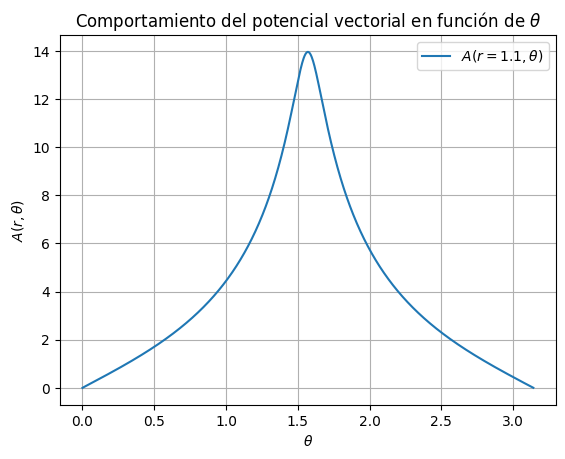

In [40]:
# Variables definidas
a = 1
I = 3
mu = 4 * np.pi
r = 1.1

theta = np.linspace(1e-12, np.pi - 1e-12, 1000)  # Variar theta
A_a = np.zeros(1000)  # Arreglo para calcular A al variar theta

# Calcular A para todos los valores de theta
for indice in range(len(theta)):
    A_a[indice] = potencial_A(r, theta[indice], a, I, mu, fe, fk)

# Graficar el comportamiento de A
plt.title(r'Comportamiento del potencial vectorial en función de $\theta$')
plt.plot(theta, A_a, label=r'$A(r=1.1,\theta)$')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$A(r,\theta)$')
plt.legend()
plt.grid()
plt.show()

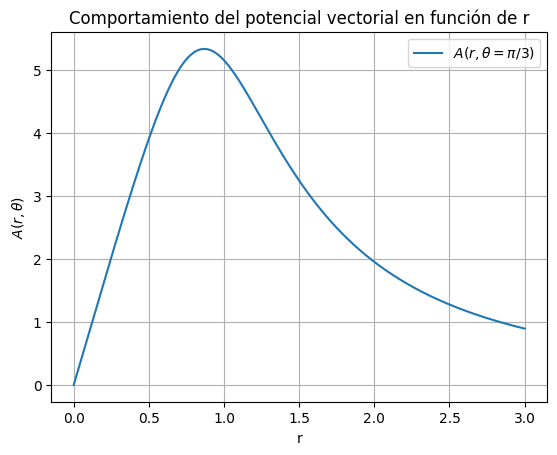

In [41]:
theta = np.pi / 3

r = np.linspace(1e-11, 3, 1000)  # Variar r
A_b = np.zeros(1000)  # Arreglo para calcular A al variar r

# Calcular A para todos los valores de r
for indice in range(len(r)):
    A_b[indice] = potencial_A(r[indice], theta, a, I, mu, fe, fk)

# Graficar el comportamiento de A
plt.title('Comportamiento del potencial vectorial en función de r')
plt.plot(r, A_b, label=r'$A(r,\theta=\pi/3)$')
plt.xlabel('r')
plt.ylabel(r'$A(r,\theta)$')
plt.legend()
plt.grid()
plt.show()

# 6.
Suponga que una onda plana con longitud de onda $\lambda$ es bloqueada por un objeto con un borde recto, representado por la línea sólida en la parte inferior de esta figura:

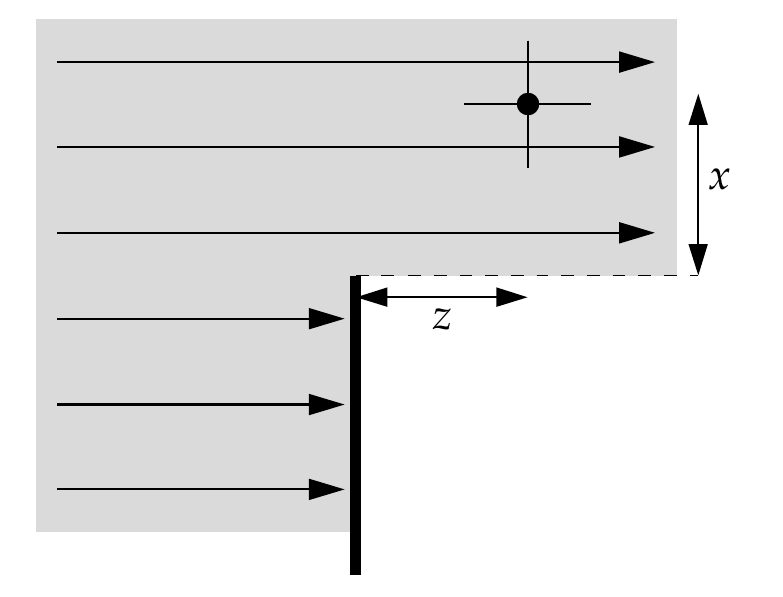

La onda se difracta en el borde, y la intensidad resultante en la posición $(x, z)$ (marcada por el punto) está dada por la teoría de difracción de campo cercano como:

$$ I = \frac{I_0}{8} \left( [2C(u) + 1]^2 + [2S(u) + 1]^2 \right)$$

donde:
- $$I_0 = \text{intensidad de la onda antes de la difracción} $$
- $$u = x \sqrt{\frac{2}{\lambda z}}$$
- $$C(u) = \int_{0}^{u} \cos \left(\frac{1}{2} \pi t^2 \right)dt
    $$ 
- $$ S(u) = \int_{0}^{u} \sin \left(\frac{1}{2} \pi t^2 \right)dt
    $$

Grafique $I/I_0$ como función de $x$ en el rango de $-5,\text{m}$ a $5,\text{m}$ para el caso de una onda sonora con longitud de onda $\lambda = 1,\text{m}$ y una distancia de medición $z = 3,\text{m}$ después del borde recto.

**Nota:** Use cuadratura gaussiana con 50 puntos.

In [42]:
# Parámetros dados
lambda_ = 1.0  # longitud de onda en metros
z = 3.0  # distancia de medición en metros
rango_x = np.linspace(-5, 5, 500)  # rango de x en metros

In [43]:
def cuadratura_gaussiana_estandar(funcion, a, b, n):
    """
    Calcula la integral de una función en el intervalo [a, b]
    usando cuadratura gaussiana.

    Parámetros:
    - funcion: función que se va a integrar.
    - n: número de puntos para la cuadratura (grado del polinomio de Legendre).

    Retorna:
    - Aproximación de la integral.
    """
    # Obtener raíces y pesos del polinomio de Legendre
    t, w = roots_legendre(n)
    x = (b - a) / 2 * t + (a + b) / 2

    # Evaluar la suma ponderada
    integral = np.sum(w * funcion(x)) * (b - a) / 2
    return integral

In [44]:
# Definir las integrales de Fresnel C(u) y S(u)
def fresnel_c(u):
    integrando = lambda t: np.cos(0.5 * np.pi * t**2)
    return cuadratura_gaussiana_estandar(integrando, 0, u, 50)

def fresnel_s(u):
    integrando = lambda t: np.sin(0.5 * np.pi * t**2)
    return cuadratura_gaussiana_estandar(integrando, 0, u, 50)

In [45]:
# Calcular I/I0 para cada x en rango_x
I_sobre_I0 = []
for x in rango_x:
    u = x * np.sqrt(2 / (lambda_ * z))
    C_u = fresnel_c(u)
    S_u = fresnel_s(u)
    intensidad = ((2 * C_u + 1)**2 + (2 * S_u + 1)**2) / 8
    I_sobre_I0.append(intensidad)

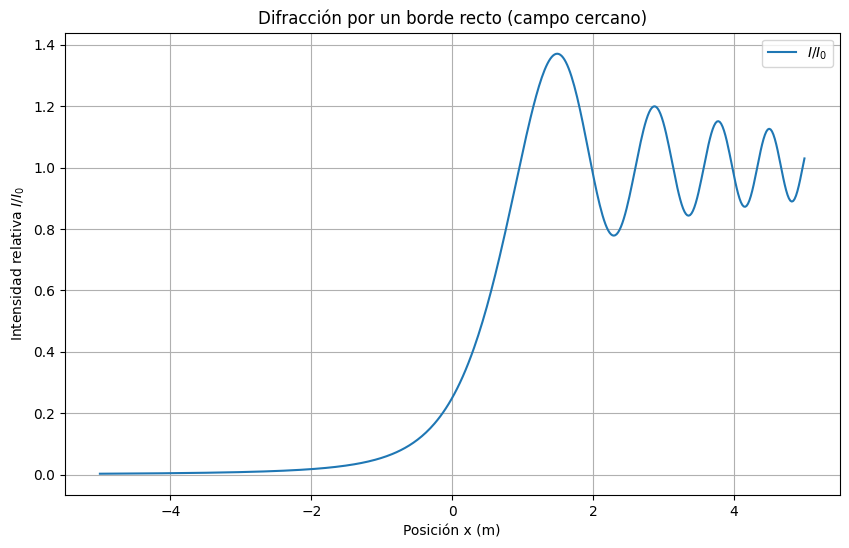

In [46]:
# Gráfica
plt.figure(figsize=(10, 6))
plt.plot(rango_x, I_sobre_I0, label=r'$I/I_0$')
plt.xlabel('Posición x (m)')
plt.ylabel(r'Intensidad relativa $I/I_0$')
plt.title('Difracción por un borde recto (campo cercano)')
plt.grid()
plt.legend()
plt.show()

## Implementación con scipy

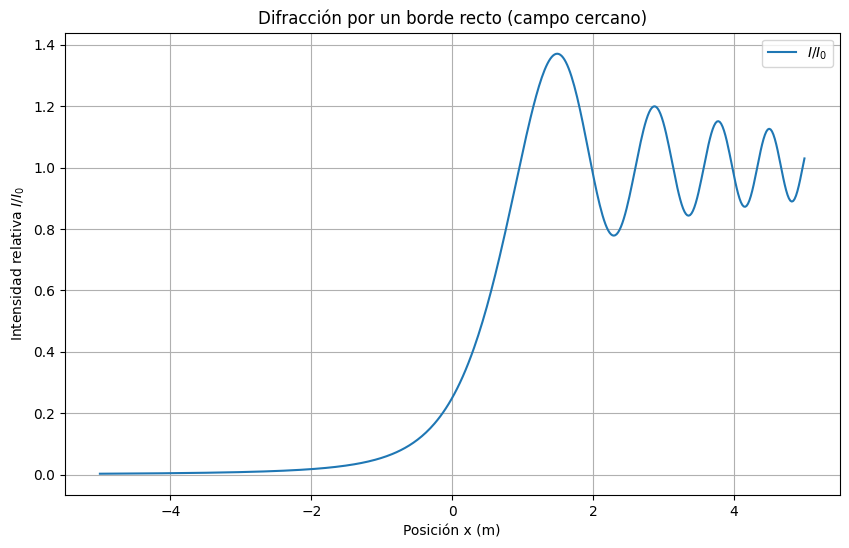

In [47]:
# Definir las integrales de Fresnel C(u) y S(u) usando fixed_quad
def fresnel_c(u):
    integrando = lambda t: np.cos(0.5 * np.pi * t**2)
    return fixed_quad(integrando, 0, u, n=50)[0]

def fresnel_s(u):
    integrando = lambda t: np.sin(0.5 * np.pi * t**2)
    return fixed_quad(integrando, 0, u, n=50)[0]

# Calcular I/I0 para cada x en rango_x
I_sobre_I0 = []
for x in rango_x:
    u = x * np.sqrt(2 / (lambda_ * z))
    C_u = fresnel_c(u)
    S_u = fresnel_s(u)
    intensidad = ((2 * C_u + 1)**2 + (2 * S_u + 1)**2) / 8
    I_sobre_I0.append(intensidad)

# Gráfica
plt.figure(figsize=(10, 6))
plt.plot(rango_x, I_sobre_I0, label=r'$I/I_0$')
plt.xlabel('Posición x (m)')
plt.ylabel(r'Intensidad relativa $I/I_0$')
plt.title('Difracción por un borde recto (campo cercano)')
plt.grid()
plt.legend()
plt.show()

# 7.
La teoría de Planck establece que, en el intervalo de frecuencia angular de $\omega$ a $\omega + d\omega$, un cuerpo negro irradia por segundo una energía térmica electromagnética igual a $I(\omega) d\omega$, donde:

$$I(\omega) = \frac{\hbar}{4\pi^2 c^2} \frac{\omega^3}{\left(e^{\hbar\omega/k_B T}-1\right)}$$

con $\hbar$ = constante de Planck reducida ($h/2\pi$), $c$ = velocidad de la luz, $k_B$ = constante de Boltzmann y $T$ = temperatura absoluta.

La energía total por unidad de área irradiada por un cuerpo negro es:

$$W = \frac{k_B^4 T^4}{4\pi^2 c^2 \hbar^3} \int_0^\infty \frac{x^3}{e^x - 1} \, dx$$

- Evalúe numéricamente la integral de esta expresión.

- Usando el valor obtenido para la integral y la ley de Stefan-Boltzmann:

$$W = \sigma T^4$$

calcule el valor de la constante de Stefan-Boltzmann $\sigma$ (en unidades SI) con tres cifras significativas. Compare con el valor conocido.

In [48]:
# Función integrando: x^3 / (e^x - 1)
def integrando_planck(x):
    return x**3 / (np.exp(x) - 1)

In [49]:
# Calcular la integral desde 0 hasta infinito
integral, error = quad(integrando_planck, 0, np.inf)
print(f"Valor de la integral: {integral:.6f}")
print(f"Error estimado: {error:.2e}")

Valor de la integral: 6.493939
Error estimado: 2.63e-09


/tmp/ipykernel_6947/2155866207.py:3: RuntimeWarning: overflow encountered in exp
  return x**3 / (np.exp(x) - 1)


## Veamos la gráfica del integrando

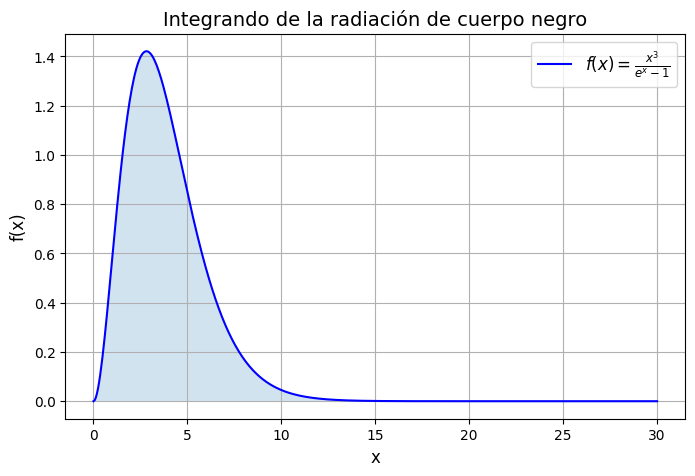

In [50]:
x_valores = np.linspace(1e-5, 30, 500)

# Gráfica
plt.figure(figsize=(8, 5))
plt.plot(x_valores, integrando_planck(x_valores), label=r'$f(x) = \frac{x^3}{e^x - 1}$', color='blue')
plt.fill_between(x_valores, integrando_planck(x_valores), alpha=0.2)
plt.title('Integrando de la radiación de cuerpo negro', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.grid()
plt.legend(fontsize=12)
plt.show()

In [51]:
# Calcular la integral desde 0 hasta 30
integral, error = quad(integrando_planck, 0, 30)
print(f"Valor de la integral: {integral:.6f}")
print(f"Error estimado: {error:.2e}")

Valor de la integral: 6.493939
Error estimado: 1.37e-11


In [52]:
from scipy.constants import hbar, c, k, sigma

In [53]:
# Calcular sigma usando W = sigma * T^4
sigma_calculada = (k**4) / (4 * np.pi**2 * c**2 * hbar**3) * integral
print(f"Constante de Stefan-Boltzmann calculada: {sigma_calculada:.3e} W m⁻² K⁻⁴")

# Valor conocido de sigma
sigma_conocida = sigma
print(f"Valor conocido de sigma: {sigma_conocida:.3e} W m⁻² K⁻⁴")

# Comparación porcentual
error_porcentual = abs(sigma_calculada - sigma_conocida) / sigma_conocida * 100
print(f"Error porcentual: {error_porcentual}%")

Constante de Stefan-Boltzmann calculada: 5.670e-08 W m⁻² K⁻⁴
Valor conocido de sigma: 5.670e-08 W m⁻² K⁻⁴
Error porcentual: 4.30651098678863e-08%


# 8.
La función de onda del electrón en el estado $3d_0$ ($n=3$, $l=2$, $m=0$) en unidades radiales adimensionales es:

$$\Psi_{320}(r,\theta,\varphi) = \frac{1}{81\sqrt{6\pi}} r^2 e^{-r/3} (3\cos^2\theta - 1)$$

La probabilidad total de localizar el electrón debe satisfacer:

$$ \int_0^{2\pi} \int_0^\pi \int_0^\infty  |\Psi_{320}(r,\theta,\varphi)|^2 \, r^2 \, \sin\theta dr  d\theta d\varphi = 1$$

Verifique numéricamente esta normalización.

In [54]:
# Función para la parte radial: r^6 * exp(-2r/3)
def integrando_radial(r):
    return r**6 * np.exp(-2 * r / 3)

# Función para la parte angular: (3cos²θ - 1)^2 * sinθ
def integrando_angular(theta):
    return (3 * np.cos(theta)**2 - 1)**2 * np.sin(theta)

# Calcular la integral radial
integral_radial = quad(integrando_radial, 0, np.inf)[0]
print(f"Parte radial: {integral_radial:.6f}")

# Calcular la integral angular
integral_angular = quad(integrando_angular, 0, np.pi)[0]
print(f"Parte angular: {integral_angular:.6f}")

# Integral azimutal (trivial)
integral_azimutal = 2 * np.pi
print(f"Parte azimutal: {integral_azimutal:.6f}")

# Valor total de la integral de normalización
normalizacion = (1 / (81 * np.sqrt(6 * np.pi)))**2 * integral_radial * integral_angular * integral_azimutal
print(f"Valor de la integral de normalización: {normalizacion:.6f}")

Parte radial: 12301.875000
Parte angular: 1.600000
Parte azimutal: 6.283185
Valor de la integral de normalización: 1.000000


In [55]:
def integrando_normalizacion(r, theta, phi):
    psi = (1 / (81 * np.sqrt(6 * np.pi))) * r**2 * np.exp(-r / 3) * (3 * np.cos(theta)**2 - 1)
    return np.abs(psi)**2 * r**2 * np.sin(theta)

resultado, error = tplquad(
    integrando_normalizacion,
    0, 2 * np.pi,  # phi
    0, np.pi,      # theta
    0, np.inf      # r
)

print("Resultado con tplquad:", resultado)
print("Error estimado:", error)

Resultado con tplquad: 0.9999999999998341
Error estimado: 3.5838567904089482e-09
